```raw
---
title: "Clustering for Portfolio Diversification"
format:
  jupyter: default
  html:
    code-fold: true
jupyter: python3
---
```

### [Clustering for Portfolio Diversification](https://medium.com/@simplifiedzone/ee076844bc7f)

> Machine Learning for Quants (Part 5)

In [1]:
!pip install --quiet yfinance

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

from IPython.display import display, HTML

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
#pd.options.display.float_format = '{:.4f}'.format
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Define a basket of diverse tickers
# Tech (AAPL, MSFT), Energy (XOM, CVX), Defensive (KO, JNJ), Banks (JPM, BAC)
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA',  # Tech
           'XOM', 'CVX', 'COP',                      # Energy
           'KO', 'JNJ', 'PG',                        # Defensive/Staples
           'JPM', 'BAC', 'GS']                       # Financials

# Download 2 years of data
data = yf.download(tickers, start='2024-01-01', end='2026-01-01', progress=False)['Close']

# Calculate Daily Returns
returns = data.pct_change().dropna()

print(f"Data Shape: {returns.shape}")
display(returns.sample(15))

Data Shape: (501, 14)


Ticker,AAPL,AMZN,BAC,COP,CVX,GOOGL,GS,JNJ,JPM,KO,MSFT,NVDA,PG,XOM
Date,,,,,,,,,,,,,,
2025-06-13,-0.0138,-0.0053,-0.0119,0.0240,0.0065,-0.0059,-0.0185,0.0028,-0.0123,-0.0099,-0.0082,-0.0209,-0.0178,0.0218
2024-04-18,-0.0057,-0.0114,0.0153,-0.0041,0.0075,0.0035,-0.0020,0.0067,0.0065,0.0068,-0.0184,0.0076,0.0086,-0.0009
2025-07-03,0.0052,0.0159,0.0045,-0.0080,0.0026,0.0050,0.0109,0.0029,0.0186,0.0062,0.0158,0.0133,-0.0023,0.0104
2024-08-15,0.0135,0.0440,0.0057,0.0174,0.0147,0.0058,0.0006,0.0038,0.0062,0.0010,0.0118,0.0405,-0.0052,0.0062
2024-06-03,0.0093,0.0108,-0.0028,-0.0224,-0.0298,0.0039,-0.0034,0.0073,-0.0040,0.0000,-0.0039,0.0490,0.0007,-0.0240
2025-08-01,-0.0250,-0.0827,-0.0341,-0.0271,-0.0016,-0.0144,-0.0194,0.0157,-0.0232,0.0143,-0.0176,-0.0233,0.0012,-0.0179
2025-07-09,0.0054,0.0145,-0.0066,-0.0132,-0.0014,0.0130,-0.0010,0.0031,0.0013,-0.0108,0.0139,0.0180,-0.0023,-0.0034
2024-07-02,0.0162,0.0142,0.0230,-0.0021,0.0015,0.0123,0.0042,-0.0028,0.0165,-0.0021,0.0056,-0.0131,0.0073,-0.0068
2024-04-11,0.0433,0.0167,-0.0082,0.0008,-0.0048,0.0209,-0.0082,-0.0094,-0.0002,0.0022,0.0110,0.0411,-0.0089,-0.0034


,Return,Volatility
Ticker,,
AAPL,0.2351,0.2789
AMZN,0.2662,0.3140
BAC,0.2986,0.2479
COP,-0.0423,0.2869
CVX,0.0779,0.2188
GOOGL,0.4609,0.3026
GS,0.4740,0.2859
JNJ,0.1757,0.1747
JPM,0.3673,0.2417


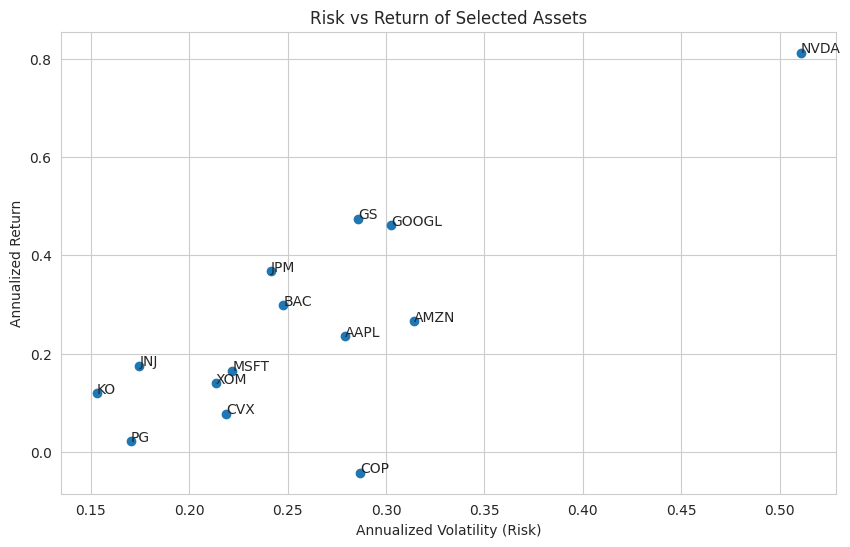

In [4]:
# 1. Calculate Annualized Mean Return (approx 252 trading days)
mean_returns = returns.mean() * 252

# 2. Calculate Annualized Volatility (Standard Deviation)
volatility = returns.std() * np.sqrt(252)

# 3. Create a DataFrame for Features
features = pd.DataFrame()
features['Return'] = mean_returns
features['Volatility'] = volatility
features.index = mean_returns.index

display(features)

# Visualization before Clustering
plt.figure(figsize=(10, 6))
plt.scatter(features['Volatility'], features['Return'])

# Annotate points
for i, txt in enumerate(features.index):
    plt.annotate(txt, (features['Volatility'].iloc[i], features['Return'].iloc[i]))

plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.title('Risk vs Return of Selected Assets')
plt.grid(True)
plt.show()

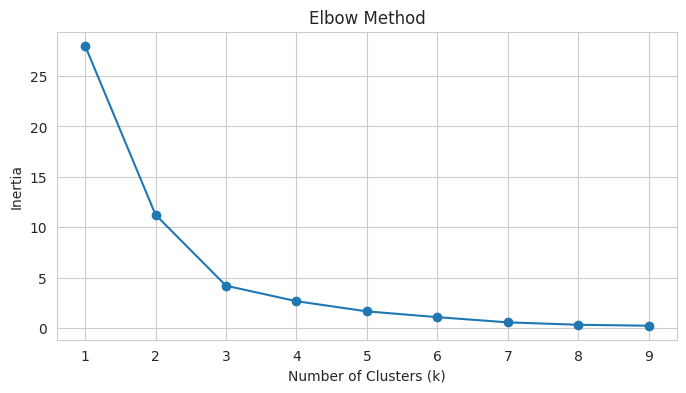

In [5]:
# 1. Scale the Data (Crucial for K-Means)
# If we don't scale, Volatility (0.20) and Return (0.15) might be comparable,
# but if we added "Price" (150.0), it would dominate the distance calculation.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 2. Elbow Method to find optimal K
inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

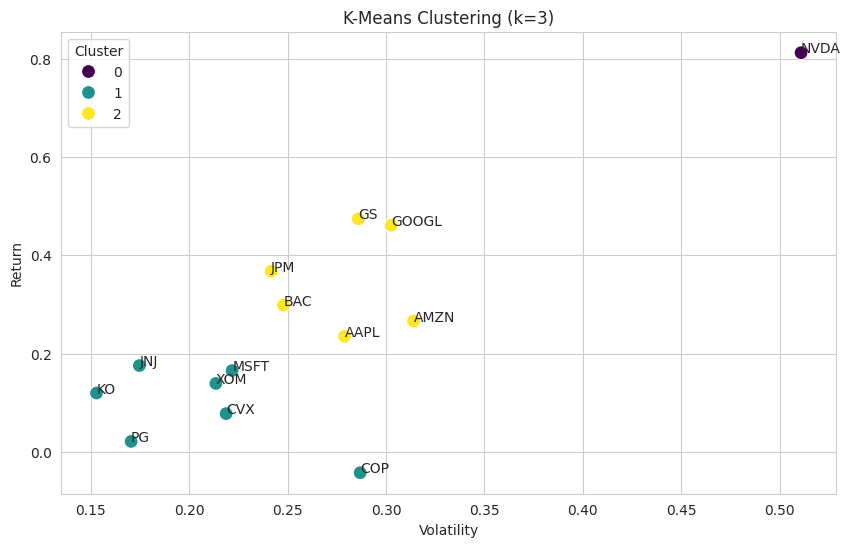


Cluster 0:
['NVDA']

Cluster 1:
['COP', 'CVX', 'JNJ', 'KO', 'MSFT', 'PG', 'XOM']

Cluster 2:
['AAPL', 'AMZN', 'BAC', 'GOOGL', 'GS', 'JPM']


In [6]:
# Apply K-Means with chosen k
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add Cluster labels to original data
features['Cluster'] = clusters

# Visualize Clusters
plt.figure(figsize=(10, 6))
# Plot each cluster with a different color
sns.scatterplot(data=features, x='Volatility', y='Return', hue='Cluster', palette='viridis', s=100)

for i, txt in enumerate(features.index):
    plt.annotate(txt, (features['Volatility'].iloc[i], features['Return'].iloc[i]))

plt.title(f'K-Means Clustering (k={k})')
plt.grid(True)
plt.show()

# Show which stocks are in which cluster
for i in range(k):
    print(f"\nCluster {i}:")
    print(features[features['Cluster'] == i].index.tolist())

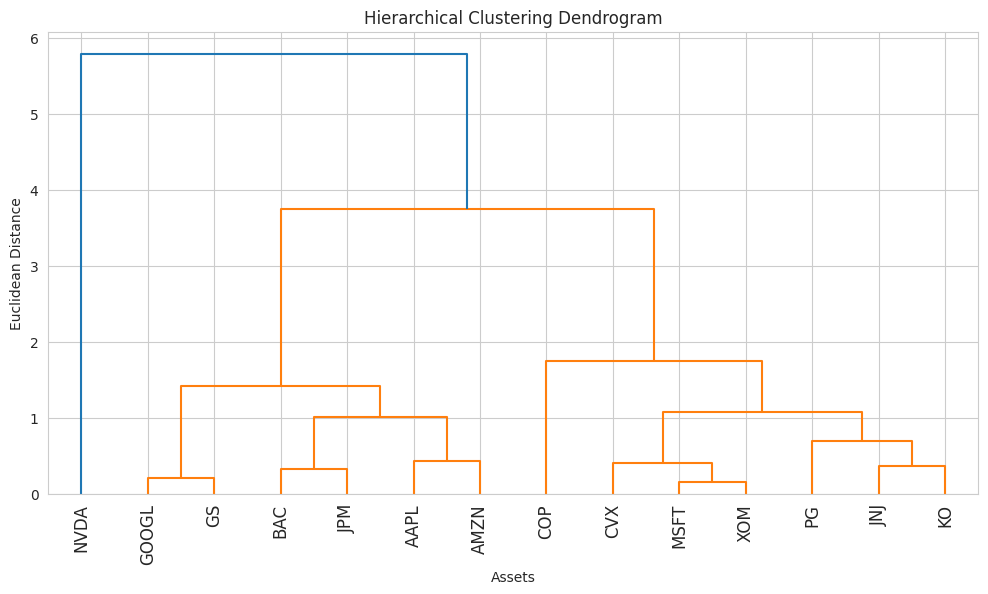

In [7]:
# 1. Compute Linkage Matrix (Ward's method minimizes variance within clusters)
# We use the SCALED data (X_scaled)
Z = linkage(X_scaled, method='ward')

# 2. Plot Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    labels=features.index,
    leaf_rotation=90,
    leaf_font_size=12,
)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Assets')
plt.ylabel('Euclidean Distance')
plt.show()